<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/Linear%20Algebra/Chapter_3_Determinant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import sympy as sy
# sy.init_printing()
import matplotlib.pyplot as plt
# plt.style.use('ggplot')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

In [3]:
def round_expr(expr, num_digits):
    return expr.xreplace({n : round(n, num_digits) for n in expr.atoms(sy.Number)})

# <font face="gotham" color="purple"> Visualization of Determinants</font>

The physical interpretation of determinants is to compute the area enclosed by vectors. For instance, consider the matrix
$$
A = \left[\begin{matrix} a & b \\ c & d \end{matrix}\right]
$$
The determinant represents the area of the parallelogram formed by the vectors
$$
\left[\begin{matrix} a \\ c \end{matrix}\right] \quad \text{and} \quad \left[\begin{matrix} b \\ d \end{matrix}\right]
$$

Here we demonstrate with a matrix
$$
\left[\begin{matrix} 2 & 0\cr 0 & 3 \end{matrix}\right]
$$
It's also easy to understand the area formed by these two vectors are actually a rectangle.

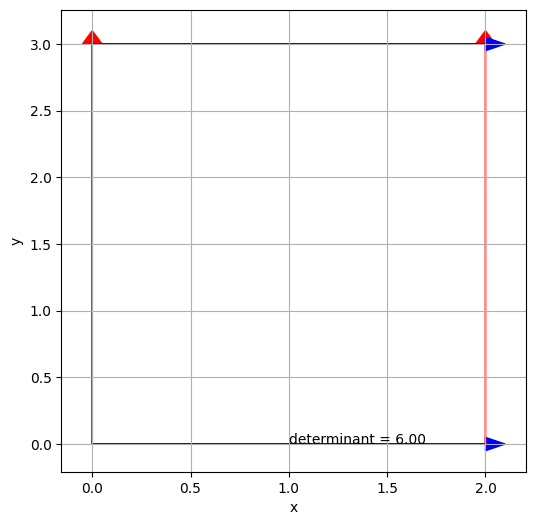

In [4]:
matrix = np.array([[2, 0], [0, 3]])
def plot_2ddet(matrix):
    # Calculate the determinant of the matrix
    det = np.linalg.det(matrix)

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot the vectors
    ax.arrow(0, 0, matrix[0,0], matrix[0,1], head_width=0.1, head_length=0.1, color='b')
    ax.arrow(0, 0, matrix[1,0], matrix[1,1], head_width=0.1, head_length=0.1, color='r')
    ax.arrow(matrix[0,0], matrix[0,1], matrix[1,0], matrix[1,1], head_width=0.1, head_length=0.1, color='r')
    ax.arrow(matrix[1,0], matrix[1,1], matrix[0,0], matrix[0,1], head_width=0.1, head_length=0.1, color='b')

    # Annotate the determinant value
    ax.annotate(f'determinant = {det:.2f}', (matrix[0,0]/2, matrix[0,1]/2))

    # Add labels and show the plot
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid()
    plt.show()

if __name__ == '__main__':
    plot_2ddet(matrix)

# <font face="gotham" color="purple"> Computation of Determinants</font>

For $2\times 2$ matrix $A$, the algorithm of determinant is
$$
  A=\left|\begin{matrix} a & b\cr c & d \end{matrix}\right| \qquad\text{is equivalent to}\qquad \text{det}  A=ad-bc
$$

Now we experiment with SymPy

In [7]:
a, b, c, d, e, f, g, h, i = sy.symbols('a, b, c, d, e, f, g, h, i', real = True)
A = sy.Matrix([[a, b], [c, d]])
A.det()


a*d - b*c

In [9]:
a,b,c,d = 2,0,0,3
A = sy.Matrix([[a, b], [c, d]])
A.det()

6

With defined symbols, the algorithms of $2\times 2$ and $3\times 3$ determinants are

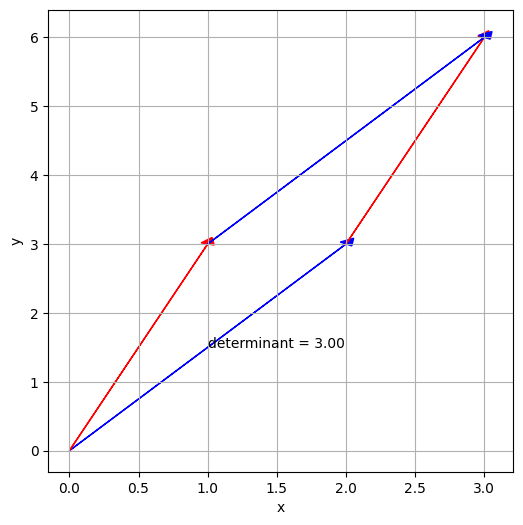

In [5]:
matrix = np.array([[2, 3], [1, 3]])
plot_2ddet(matrix)

In [11]:
a,b,c,d = 2,3,1,3
A = sy.Matrix([[a, b], [c, d]])
A.det()

3

However, determinant can be a _negative number_, it means we flip the area like flipping a piece of paper.

What if two vectors are linearly dependent? The area between vectors will be zero.

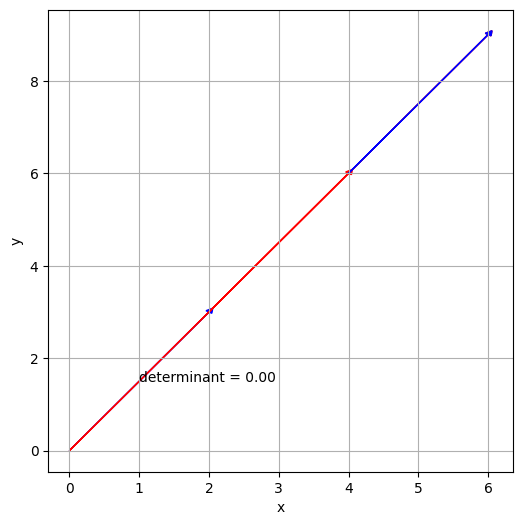

In [6]:
matrix = np.array([[2, 3], [4, 6]])
plot_2ddet(matrix)

In [12]:
a,b,c,d = 2,3,4,6
A = sy.Matrix([[a, b], [c, d]])
A.det()

0

<div style="background-color:Bisque; color:DarkBlue; padding:30px;">
This is the exact reason if we want a matrix to have full rank or linear independent columns, the determinant can't equal to zero!
</div>

Here's a plot of parallelepiped, in case you are not sure how it looks.

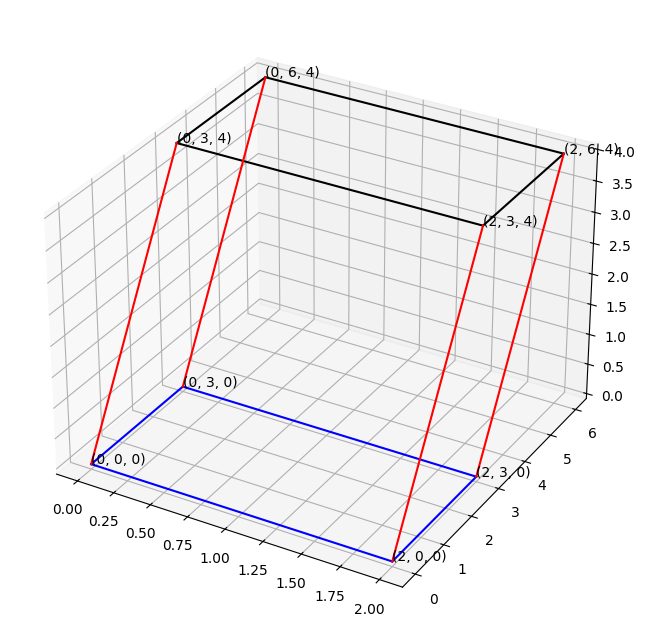

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Define the vertices of the parallelepiped
vertices = np.array([[2, 0, 0], [2, 3, 0], [0, 3, 0], [0, 0, 0],
                     [2, 3, 4], [2, 6, 4], [0, 6, 4], [0, 3, 4]])

# Plot edges between corresponding vertices
def plot_edges(vertices, pairs, color):
    for (i, j) in pairs:
        ax.plot([vertices[i, 0], vertices[j, 0]],
                [vertices[i, 1], vertices[j, 1]],
                [vertices[i, 2], vertices[j, 2]], color=color)

# Pairs of indices representing edges to be plotted
bottom_edges = [(i, (i+1)%4) for i in range(4)]
top_edges = [(i+4, (i+1)%4+4) for i in range(4)]
vertical_edges = [(i, i+4) for i in range(4)]

# Plot all edges
plot_edges(vertices, bottom_edges, 'blue')
plot_edges(vertices, top_edges, 'k')
plot_edges(vertices, vertical_edges, 'red')

# Add annotations for the coordinates at each vertex
for vertex in vertices:
    ax.text(vertex[0], vertex[1], vertex[2], f"({vertex[0]}, {vertex[1]}, {vertex[2]})")

plt.show()

Anything above than $2 \times 2$ is become more complicated

In [14]:
B = sy.Matrix([[a, b, c], [d, e, f], [g, h, i]])
B.det()

-4*e*g + 2*e*i + 3*f*g - 2*f*h + 24*h - 18*i

If the matrix is not diagonal, the area will take the form of a parallelogram. Similarly, in 3D space, the determinant is the volume of a parallelepiped. First let's draw a parallelogram.

### **[실전문제] 위의 3개 vecotr의 determinant는?**

$$A = \begin{bmatrix} 2 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 3 & 4 \end{bmatrix}$$

In [15]:
a, b, c, d, e, f, g, h, i =  2, 0, 0, 0, 3, 0, 0, 3, 4
B = sy.Matrix([[a, b, c], [d, e, f], [g, h, i]])
B.det()

24

# <font face="gotham" color="purple"> A Determinant Formula For Inverse Matrix</font>

## <font face="gotham" color="purple"> A SymPy Example</font>

Generate a random matrix with $20\%$ of zero elements.

In [20]:
A = sy.randMatrix(5, min=-5, max = 5, percent = 80); A

Matrix([
[3, -4,  0, -4, 0],
[0,  4, -3,  0, 3],
[5,  5, -5, -2, 2],
[0, -5,  2,  1, 3],
[0, -2,  2,  0, 0]])

###  determinant로 역행렬 구하기

In [21]:
# 2. 행렬식(Determinant) 계산
det_A = A.det()

# 3. 역행렬 구하기 (adjugate 없이 여인수 행렬의 전치 이용)
# Step 3-1: 여인수 행렬(Cofactor Matrix) 구하기
cof_mat = A.cofactor_matrix()

# Step 3-2: 여인수 행렬을 전치(Transpose)하여 수반 행렬(Adjugate) 생성
adj_mat = cof_mat.T

# Step 3-3: 행렬식으로 나누어 최종 역행렬(A_inv) 도출
A_inv = adj_mat / det_A

In [22]:
A_inv

Matrix([
[-13/111, -28/111, 10/37, 8/111,  25/111],
[  -5/74,    6/37,  3/74, -7/37,  79/148],
[  -5/74,    6/37,  3/74, -7/37, 153/148],
[ -10/37,  -13/37,  6/37,  9/37,  -27/74],
[  5/222,  31/111, -1/74, 7/111, 143/444]])

In [23]:
# 4. 내적 연산 (A @ A_inv) 및 단위 행렬 확인
identity_check = A @ A_inv
identity_check

Matrix([
[1, 0, 0, 0, 0],
[0, 1, 0, 0, 0],
[0, 0, 1, 0, 0],
[0, 0, 0, 1, 0],
[0, 0, 0, 0, 1]])

### 2. numpy의 선형대수 함수로 역행렬 간단하게 구하기

In [24]:
type(A)

sympy.matrices.dense.MutableDenseMatrix

In [31]:
A_np = np.array(A).astype(float) # Convert SymPy matrix A to a NumPy array with float dtype
print("Converted A to NumPy array:")
print(f"Type of A_numpy: {type(A_np)}")
A_np

Converted A to NumPy array:
Type of A_numpy: <class 'numpy.ndarray'>


array([[ 3., -4.,  0., -4.,  0.],
       [ 0.,  4., -3.,  0.,  3.],
       [ 5.,  5., -5., -2.,  2.],
       [ 0., -5.,  2.,  1.,  3.],
       [ 0., -2.,  2.,  0.,  0.]])

In [44]:
(A_np/det_A_np)@A_np

array([[ 0.02 , -0.018,  0.009, -0.036, -0.054],
       [-0.034, -0.011,  0.02 ,  0.014,  0.014],
       [-0.023, -0.043,  0.023, -0.027, -0.002],
       [ 0.023, -0.047,  0.029, -0.007, -0.018],
       [ 0.023,  0.005, -0.009, -0.009, -0.005]])

In [49]:
# 1. 역행렬(Inverse Matrix) 구하기
# np.linalg.inv() 함수를 사용합니다.
A_inv = np.linalg.inv(A_np)
A_inv

# 2. 행렬 A와 역행렬의 곱 (A @ A_inv)
# @ 연산자 또는 np.dot()을 사용합니다.
identity_check = A_np @ A_inv
identity_check


print("\n 내적 결과 (A @ A_inv):")
# 부동 소수점 오차를 제거하고 보기 좋게 출력하기 위해 round 처리
print(np.round(identity_check, 10))

array([[-0.117, -0.252,  0.27 ,  0.072,  0.225],
       [-0.068,  0.162,  0.041, -0.189,  0.534],
       [-0.068,  0.162,  0.041, -0.189,  1.034],
       [-0.27 , -0.351,  0.162,  0.243, -0.365],
       [ 0.023,  0.279, -0.014,  0.063,  0.322]])

array([[ 1.,  0., -0.,  0.,  0.],
       [ 0.,  1., -0., -0., -0.],
       [-0.,  0.,  1.,  0.,  0.],
       [-0., -0., -0.,  1., -0.],
       [-0., -0.,  0.,  0.,  1.]])


 내적 결과 (A @ A_inv):
[[ 1.  0. -0.  0.  0.]
 [ 0.  1. -0. -0. -0.]
 [-0.  0.  1.  0.  0.]
 [-0. -0. -0.  1. -0.]
 [-0. -0.  0.  0.  1.]]


In [33]:
A@A.inv()

Matrix([
[1, 0, 0, 0, 0],
[0, 1, 0, 0, 0],
[0, 0, 1, 0, 0],
[0, 0, 0, 1, 0],
[0, 0, 0, 0, 1]])

## **실전 문제 **
- 연립방정식 예시다음과 같은 3원 1차 연립방정식을 해를 구하라
$$\begin{cases}
2x + 0y + 0z = 4 \\
0x + 3y + 0z = 9 \\
0x + 3y + 4z = 17
\end{cases}$$


- 이를 행렬 형태 $Ax = B$로 나타내면:

$$\begin{bmatrix}
2 & 0 & 0 \\
0 & 3 & 0 \\
0 & 3 & 4
\end{bmatrix}
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}
=
\begin{bmatrix}
4 \\
9 \\
17
\end{bmatrix}$$

선형대수학을 이용한 연립방정식의 풀이주어진 3원 1차 연립방정식은 다음과 같은 **행렬 방정식(Matrix Equation)**으로 정의됩니다.1. 행렬 방정식 정의 ($Ax = B$)$$A = \begin{bmatrix} 2 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 3 & 4 \end{bmatrix}, \quad \mathbf{x} = \begin{bmatrix} x \\ y \\ z \end{bmatrix}, \quad \mathbf{b} = \begin{bmatrix} 4 \\ 9 \\ 17 \end{bmatrix}$$이때, 선형 변환의 관점에서 이 문제는 "행렬 $A$에 의해 변환된 벡터 $\mathbf{x}$가 결과 벡터 $\mathbf{b}$와 같아지도록 하는 원래의 $\mathbf{x}$를 찾는 것"과 같습니다.2. 가역성(Invertibility) 확인행렬 $A$의 역행렬 $A^{-1}$이 존재하기 위한 필요충분조건은 행렬식(Determinant)이 0이 아니어야 합니다($\det(A) \neq 0$).$$\det(A) = 2 \cdot \begin{vmatrix} 3 & 0 \\ 3 & 4 \end{vmatrix} - 0 + 0 = 2(12 - 0) = 24$$$\det(A) = 24 \neq 0$ 이므로, 행렬 $A$는 **비특이 행렬(Non-singular Matrix)**이며 유일한 역행렬을 가집니다.3. 역행렬 도출 ($A^{-1}$)역행렬의 정의에 따라 $A^{-1} = \frac{1}{\det(A)} \text{adj}(A)$를 적용합니다. 여기서 $\text{adj}(A)$는 여인수 행렬의 전치 행렬입니다.$$A^{-1} = \frac{1}{24} \begin{bmatrix} 12 & 0 & 0 \\ 0 & 8 & 0 \\ 0 & -6 & 6 \end{bmatrix} = \begin{bmatrix} \frac{1}{2} & 0 & 0 \\ 0 & \frac{1}{3} & 0 \\ 0 & -\frac{1}{4} & \frac{1}{4} \end{bmatrix}$$4. 선형대수적 해법 (Linear Algebraic Solution)행렬 방정식 $Ax = B$의 양변의 왼쪽에 역행렬 $A^{-1}$을 곱합니다.$$A^{-1}(Ax) = A^{-1}B$$$$(A^{-1}A)x = A^{-1}B$$$$Ix = A^{-1}B \quad (\text{where } I \text{ is the Identity Matrix})$$$$\mathbf{x} = A^{-1}B$$이제 행렬 곱셈을 수행합니다.$$\begin{bmatrix} x \\ y \\ z \end{bmatrix} = \begin{bmatrix} \frac{1}{2} & 0 & 0 \\ 0 & \frac{1}{3} & 0 \\ 0 & -\frac{1}{4} & \frac{1}{4} \end{bmatrix} \begin{bmatrix} 4 \\ 9 \\ 17 \end{bmatrix} = \begin{bmatrix} \frac{1}{2} \cdot 4 \\ \frac{1}{3} \cdot 9 \\ -\frac{1}{4} \cdot 9 + \frac{1}{4} \cdot 17 \end{bmatrix} = \begin{bmatrix} 2 \\ 3 \\ \frac{8}{4} \end{bmatrix} = \begin{bmatrix} 2 \\ 3 \\ 2 \end{bmatrix}$$최종 결과$$\therefore \mathbf{x} = \begin{bmatrix} 2 \\ 3 \\ 2 \end{bmatrix}$$

In [50]:
A = np.array([
    [2, 0, 0],
    [0, 3, 0],
    [0, 3, 4]
]);
print("A:\n", A)
B = np.array([4, 9, 17]);
print("B:\n", B)

A = A.astype(float)
A_inv = np.linalg.inv(A)
print("A_inv:\n", A_inv)
X = A_inv@B
print("X:\n", X)

A:
 [[2 0 0]
 [0 3 0]
 [0 3 4]]
B:
 [ 4  9 17]
A_inv:
 [[ 0.5    0.     0.   ]
 [ 0.     0.333  0.   ]
 [ 0.    -0.25   0.25 ]]
X:
 [2. 3. 2.]
